# 01 — Exploratory Data Analysis
**PolicyPal AI** | India Code PDF dataset

This notebook covers:
1. Dataset overview and category distribution
2. Text length analysis (raw vs. simplified)
3. Vocabulary and vocabulary overlap
4. Readability scores (Flesch) of raw vs. summary
5. Sample records per category

In [1]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import textstat
from pathlib import Path
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

PROC_DIR  = Path('../data/processed')
SPLIT_DIR = Path('../data/splits')

## 1. Load Dataset

In [4]:
# Load all records
with open(PROC_DIR / 'all_records.json', encoding='utf-8') as f:
    records = json.load(f)

df = pd.DataFrame(records)
print(f'Total records : {len(df)}')
print(f'Columns       : {list(df.columns)}')
df.head(3)

Total records : 421
Columns       : ['id', 'source', 'category', 'title', 'raw_text', 'simple_summary', 'url', 'effective_date', 'lang', 'pdf_file']


,id,source,category,title,raw_text,simple_summary,url,effective_date,lang,pdf_file
0,93cee97d86a8_s087,IndiaCode,General,It Act — 81. Act to have overriding effect,81. Act to have overriding effect.–The provisi...,,None,None,en,it_act.pdf
1,a894029dd321_s000,IndiaCode,GST,Cgst Act — 14. The Finance Act,"14. The Finance Act, 2025 (Act 7 of 2025). \n ...",,None,None,en,cgst_act.pdf
2,a894029dd321_s003,IndiaCode,GST,Cgst Act — 174. Repeal and saving,174. Repeal and saving. \nSCHEDULE I. \nSCHEDU...,,None,None,en,cgst_act.pdf


## 2. Category Distribution

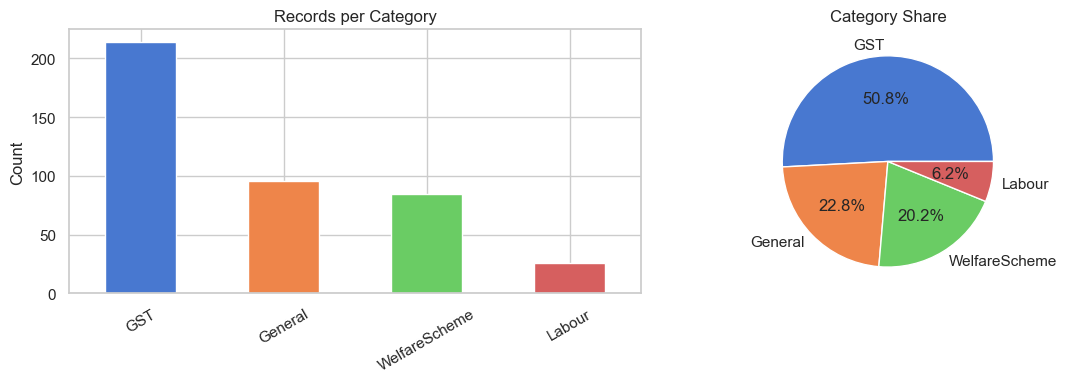

category
GST              214
General           96
WelfareScheme     85
Labour            26


In [5]:
cat_counts = df['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
cat_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(cat_counts)))
axes[0].set_title('Records per Category')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(cat_counts)))
axes[1].set_title('Category Share')

plt.tight_layout()
plt.savefig('../results/eda_category_dist.png', dpi=150)
plt.show()

print(cat_counts.to_string())

## 3. Text Length Analysis

In [8]:
import json
import pandas as pd

# 🔥 correct path
with open("../data/splits/train.json", encoding="utf-8") as f:
    train = json.load(f)

df = pd.DataFrame(train)

df['raw_words'] = df['raw_text'].apply(lambda t: len(str(t).split()))
df['summary_words'] = df['simple_summary'].apply(lambda t: len(str(t).split()))

df = df[df['raw_words'] > 0]

df['compression'] = df['summary_words'] / df['raw_words']

print('Raw text word count:')
print(df['raw_words'].describe().round(1))

print('\nSummary word count:')
print(df['summary_words'].describe().round(1))

print(f'\nMean compression ratio: {df["compression"].mean():.2%}')

Raw text word count:
count     335.0
mean      282.6
std       353.6
min        50.0
25%        94.5
50%       177.0
75%       350.0
max      4198.0
Name: raw_words, dtype: float64

Summary word count:
count    335.0
mean      27.3
std       27.3
min        0.0
25%        0.0
50%       17.0
75%       56.5
max       75.0
Name: summary_words, dtype: float64

Mean compression ratio: 19.32%


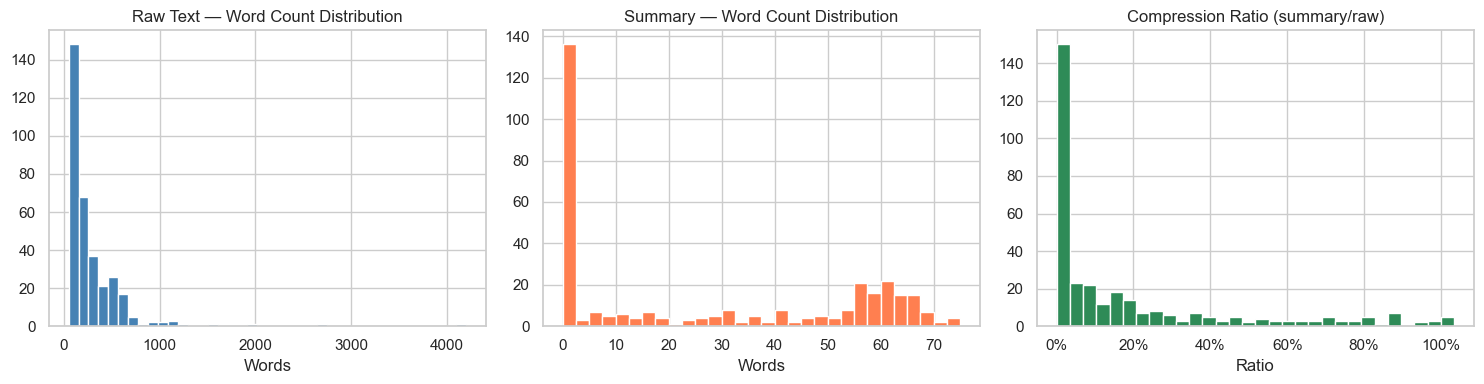

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['raw_words'],     bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Text — Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df['summary_words'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Summary — Word Count Distribution')
axes[1].set_xlabel('Words')

axes[2].hist(df['compression'],   bins=30, color='seagreen', edgecolor='white')
axes[2].set_title('Compression Ratio (summary/raw)')
axes[2].set_xlabel('Ratio')
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('../results/eda_length_dist.png', dpi=150)
plt.show()

## 4. Readability Scores

In [10]:
print('Computing Flesch scores (may take a minute) …')
df['fre_raw']     = df['raw_text'].apply(textstat.flesch_reading_ease)
df['fre_summary'] = df['simple_summary'].apply(textstat.flesch_reading_ease)
df['fkg_raw']     = df['raw_text'].apply(textstat.flesch_kincaid_grade)
df['fkg_summary'] = df['simple_summary'].apply(textstat.flesch_kincaid_grade)

print(f"Mean Flesch Reading Ease — Raw text : {df['fre_raw'].mean():.1f}")
print(f"Mean Flesch Reading Ease — Summary  : {df['fre_summary'].mean():.1f}")
print(f"Mean FK Grade Level     — Raw text : {df['fkg_raw'].mean():.1f}")
print(f"Mean FK Grade Level     — Summary  : {df['fkg_summary'].mean():.1f}")

Computing Flesch scores (may take a minute) …
Mean Flesch Reading Ease — Raw text : 10.2
Mean Flesch Reading Ease — Summary  : 33.5
Mean FK Grade Level     — Raw text : 25.4
Mean FK Grade Level     — Summary  : 9.6


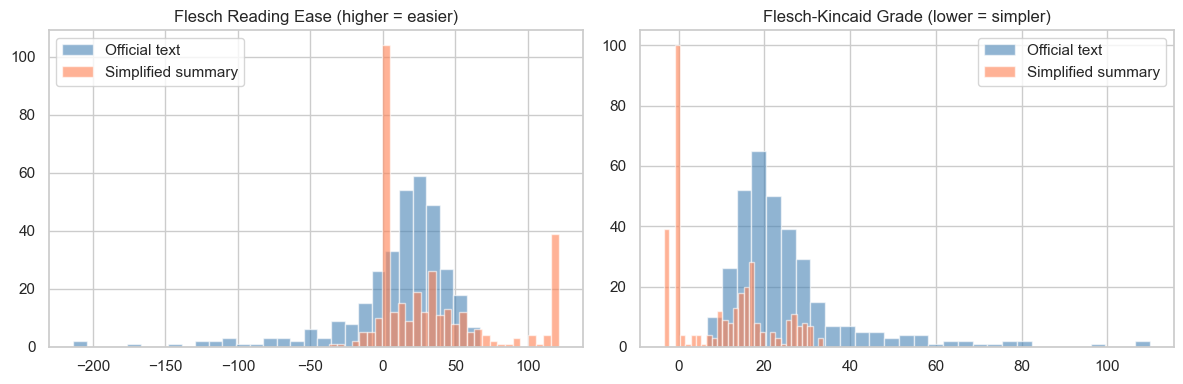

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col_raw, col_sum, title in [
    (axes[0], 'fre_raw', 'fre_summary', 'Flesch Reading Ease (higher = easier)'),
    (axes[1], 'fkg_raw', 'fkg_summary', 'Flesch-Kincaid Grade (lower = simpler)'),
]:
    ax.hist(df[col_raw], bins=30, alpha=0.6, label='Official text', color='steelblue')
    ax.hist(df[col_sum], bins=30, alpha=0.6, label='Simplified summary', color='coral')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('../results/eda_readability.png', dpi=150)
plt.show()

## 5. Top Keywords per Category

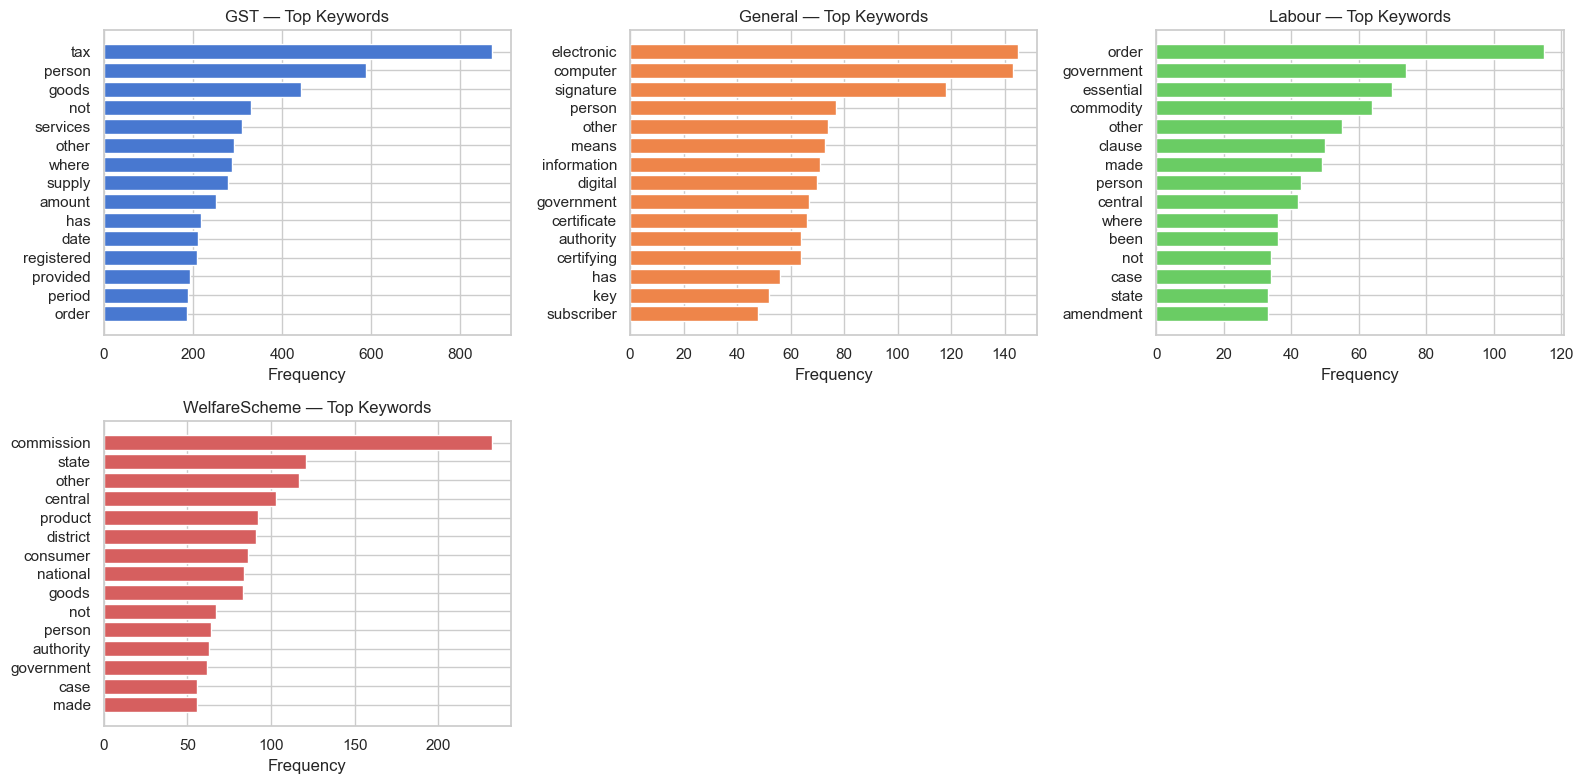

In [13]:
STOPWORDS = set("""
the a an in of to and is are was were for on with at by from as
shall may any such section act sub under this that which
""".split())

def top_words(texts, n=15):
    words = []
    for t in texts:
        words += [w.lower() for w in re.findall(r'[a-zA-Z]{3,}', t) if w.lower() not in STOPWORDS]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (cat, grp) in enumerate(df.groupby('category')):
    if i >= len(axes): break
    words, counts = zip(*top_words(grp['raw_text']))
    axes[i].barh(words[::-1], counts[::-1], color=sns.color_palette('muted')[i])
    axes[i].set_title(f'{cat} — Top Keywords')
    axes[i].set_xlabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../results/eda_keywords.png', dpi=150)
plt.show()

## 6. Split Statistics

In [15]:
for split in ['train', 'val', 'test']:
    with open(SPLIT_DIR / f'{split}.json', encoding='utf-8') as f:
        data = json.load(f)

    sdf = pd.DataFrame(data)

    print(f'\n── {split.upper()} ({len(sdf)} records) ──')
    print(sdf['category'].value_counts().to_string())


── TRAIN (335 records) ──
category
GST              171
General           76
WelfareScheme     68
Labour            20

── VAL (40 records) ──
category
GST              21
General           9
WelfareScheme     8
Labour            2

── TEST (46 records) ──
category
GST              22
General          11
WelfareScheme     9
Labour            4


## 7. Sample Records

In [16]:
for cat, grp in df.groupby('category'):
    row = grp.sample(1, random_state=42).iloc[0]
    print(f'\n{'='*60}')
    print(f'Category : {cat}')
    print(f'Source   : {row["source"]}  |  PDF: {row.get("pdf_file", "N/A")}')
    print(f'Title    : {row["title"]}')
    print(f'\nOfficial text (first 300 chars):')
    print(row['raw_text'][:300])
    print(f'\nSimplified summary:')
    print(row['simple_summary'])


Category : GST
Source   : IndiaCode  |  PDF: cgst_act.pdf
Title    : Cgst Act — 71. Access to business premises

Official text (first 300 chars):
71. Access to business premises.––(1) Any officer under this Act, authorised by the proper officer not 
below the rank of Joint Commissioner, shall have access to any place of business of a registered person to 
inspect books of account, documents, computers, computer programs, computer software whe

Simplified summary:
71. Access to business premises.––(1) Any officer under this Act, authorised by the proper officer not below the rank of Joint Commissioner, shall have access to any place of business of a registered person to inspect books of account, documents, computers, computer programs, computer software, whether installed in a computer or otherwise and such other things as he may require and which may

Category : General
Source   : IndiaCode  |  PDF: it_act.pdf
Title    : It Act — 3. Subs

Official text (first 300 chars):
3. Subs. by s